# UNSW Marketing Analytics Hackathon 2026 - Starter EDA & Baseline
This notebook/script serves as a starter template for analyzing the Kiva loans dataset 
and building a baseline model to predict **funding speed** (raisedDate - fundraisingDate).

**Goal of the Hackathon:**
Identify key factors that influence lender decision-making and funding speed 
within "subsistence marketplaces."


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src/ to path so we can import helper modules
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_and_prepare_data
from src.features import build_features
from src.modeling import run_baseline_model

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 1. Load the Kiva Loans Sample
We will use the helper functions in `src/data_loader.py` to load the pickle file 
and compute the target variable: `funding_speed_days`.


In [2]:
pkl_path = "../data/Kiva_Loans_Sample.pkl"
df = load_and_prepare_data(pkl_path)
print(f"Dataset shape: {df.shape}")
df.head(2)


Dataset shape: (100, 28)


,id,status,borrowerCount,name,gender,loanAmount,lenderRepaymentTerm,repaymentInterval,sector,activity,...,fundsLentInCountry,country_latitude,country_longitude,description,whySpecial,image_url,disbursalDate,fundraisingDate,raisedDate,funding_speed_days
0,1870768,funded,1,Josephine,female,100.0,8,monthly,Housing,Personal Housing Expenses,...,240479730,13.0,122.0,Josephine is a hardworking microentrepreneur. ...,It helps protect families who are most vulnera...,https://www.kiva.org/img/s100/33879147a8668721...,2019-10-30 07:00:00+00:00,2019-11-23 11:10:41+00:00,2019-11-23 11:24:23+00:00,0.009514
1,2961616,funded,1,Lina,female,550.0,20,monthly,Agriculture,Farming,...,164016715,1.0,38.0,"Lina, a smallholder farmer from Siongiroi, is ...",It finances smallholder farmers to purchase da...,https://www.kiva.org/img/s100/22d610a469af6a68...,2025-04-11 07:00:00+00:00,2025-04-21 21:22:30+00:00,2025-05-08 11:47:23+00:00,16.600613


## 2. Exploratory Data Analysis (EDA)
Let's inspect the target variable: `funding_speed_days`.


--- Funding Speed (Days) Summary Statistics ---
count    100.000000
mean       8.072337
std       10.859570
min        0.007326
25%        0.203831
50%        2.571412
75%       15.051554
max       35.001366
Name: funding_speed_days, dtype: float64


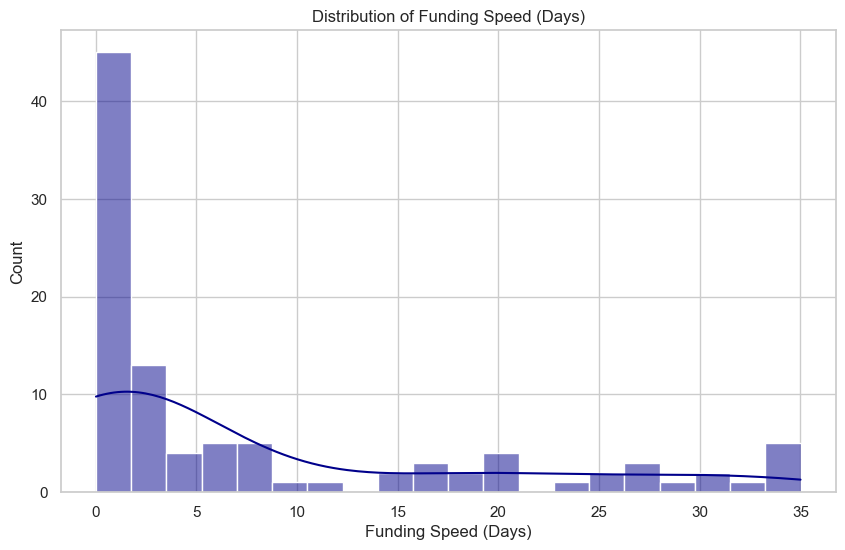

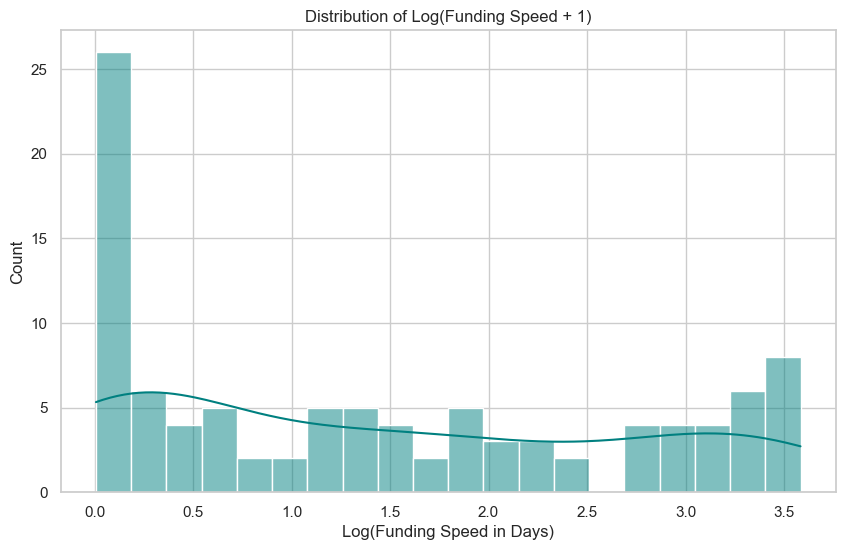

In [3]:
# Target Summary Stats
print("--- Funding Speed (Days) Summary Statistics ---")
print(df['funding_speed_days'].describe())

# Plot Distribution
plt.figure()
sns.histplot(df['funding_speed_days'], kde=True, bins=20, color='darkblue')
plt.title('Distribution of Funding Speed (Days)')
plt.xlabel('Funding Speed (Days)')
plt.ylabel('Count')
plt.show()

# Log Target Distribution (highly right-skewed)
plt.figure()
sns.histplot(np.log1p(df['funding_speed_days']), kde=True, bins=20, color='teal')
plt.title('Distribution of Log(Funding Speed + 1)')
plt.xlabel('Log(Funding Speed in Days)')
plt.ylabel('Count')
plt.show()


### 2.1 Loan Amount vs. Funding Speed
Let's see if larger loans take longer to get funded.


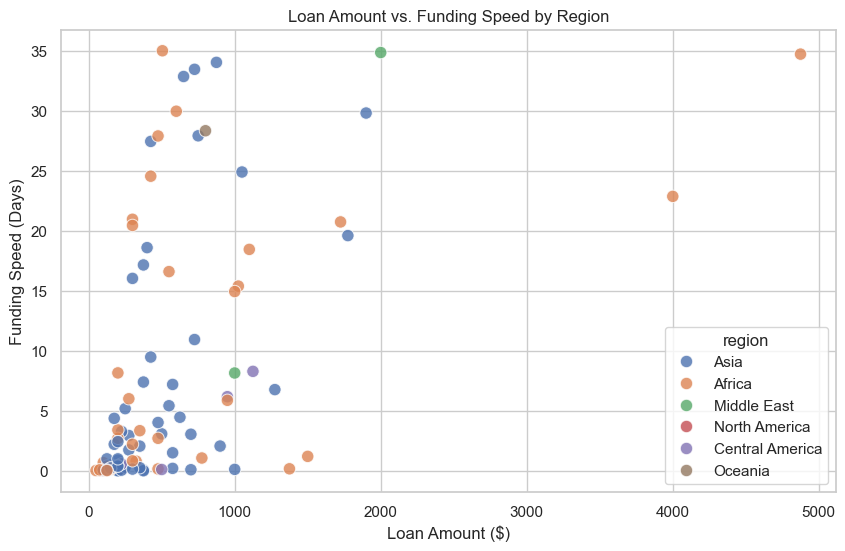

Correlation between Loan Amount and Funding Speed: 0.514


In [4]:
plt.figure()
sns.scatterplot(data=df, x='loanAmount', y='funding_speed_days', hue='region', alpha=0.8, s=80)
plt.title('Loan Amount vs. Funding Speed by Region')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Funding Speed (Days)')
plt.show()

# Correlation
corr = df['loanAmount'].corr(df['funding_speed_days'])
print(f"Correlation between Loan Amount and Funding Speed: {corr:.3f}")


### 2.2 Sector and Repayment Term vs. Funding Speed
Prosocial lenders might prioritize specific sectors (e.g., Education, Health) or prefer shorter repayment periods.


F:\Storage\Temp\ipykernel_26456\2486201448.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sector', y='funding_speed_days', order=order, palette='viridis')


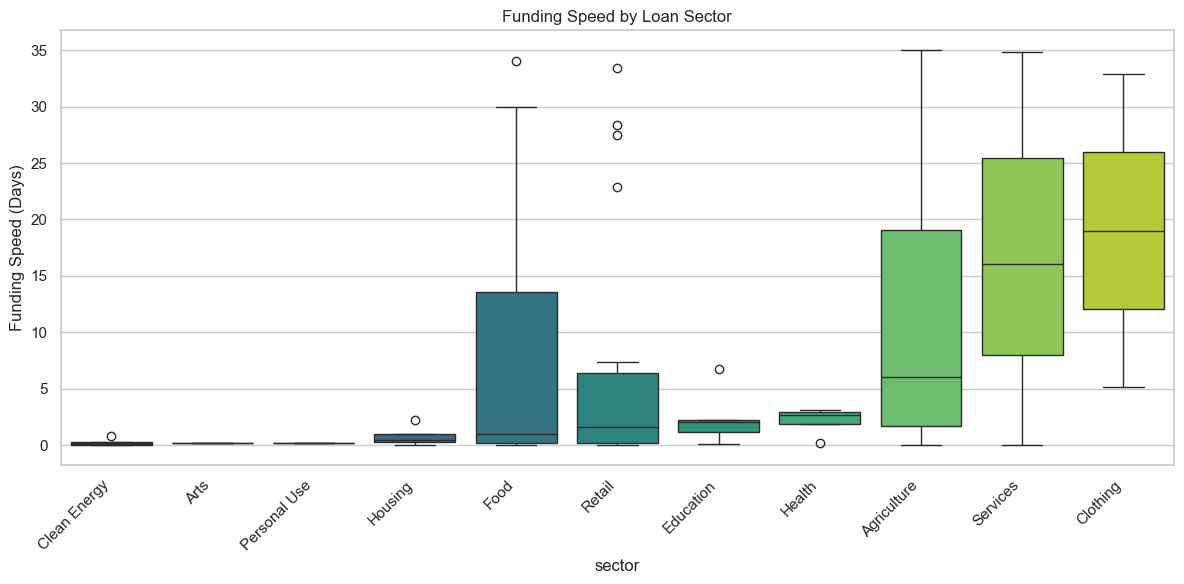

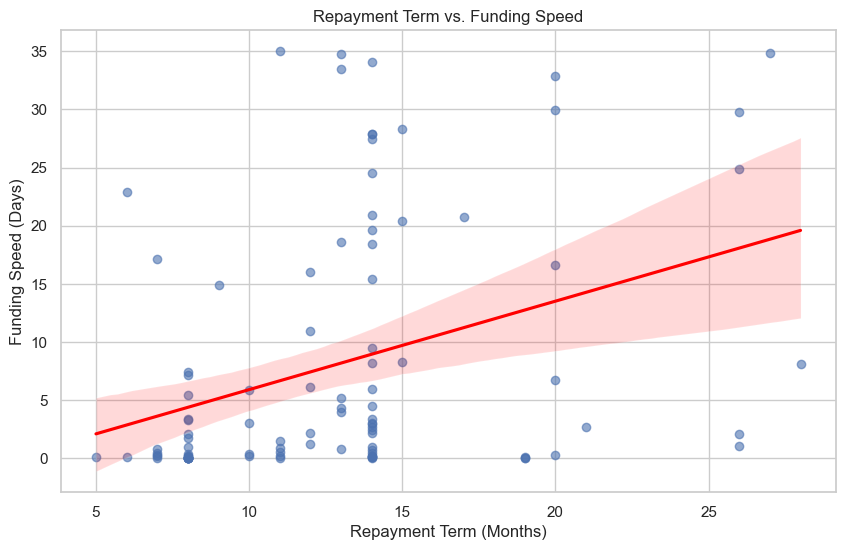

In [5]:
# Sector boxplot
plt.figure(figsize=(12, 6))
order = df.groupby('sector')['funding_speed_days'].median().sort_values().index
sns.boxplot(data=df, x='sector', y='funding_speed_days', order=order, palette='viridis')
plt.title('Funding Speed by Loan Sector')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Funding Speed (Days)')
plt.tight_layout()
plt.show()

# Repayment term vs. Funding speed
plt.figure()
sns.regplot(data=df, x='lenderRepaymentTerm', y='funding_speed_days', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Repayment Term vs. Funding Speed')
plt.xlabel('Repayment Term (Months)')
plt.ylabel('Funding Speed (Days)')
plt.show()


### 2.3 Gender & Group Loans
Does the borrower gender or group structure affect funding speed?


F:\Storage\Temp\ipykernel_26456\700904763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_group', y='funding_speed_days', palette='pastel')


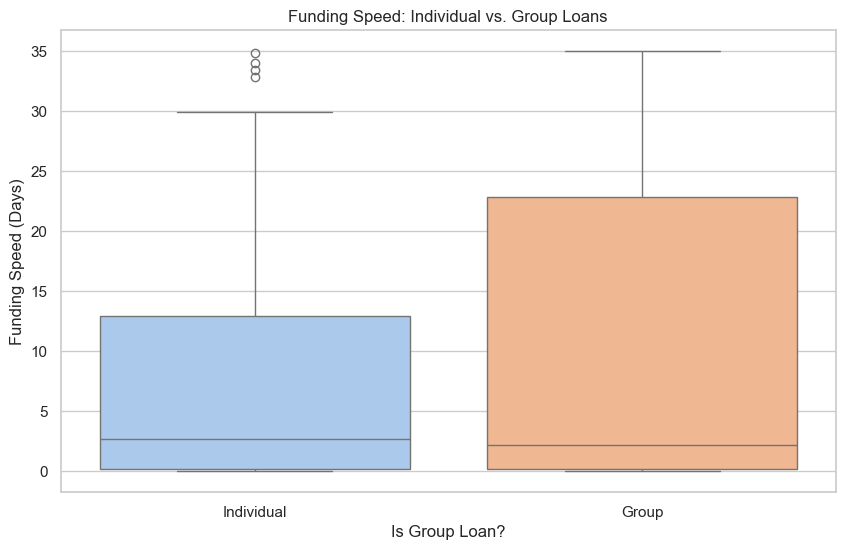

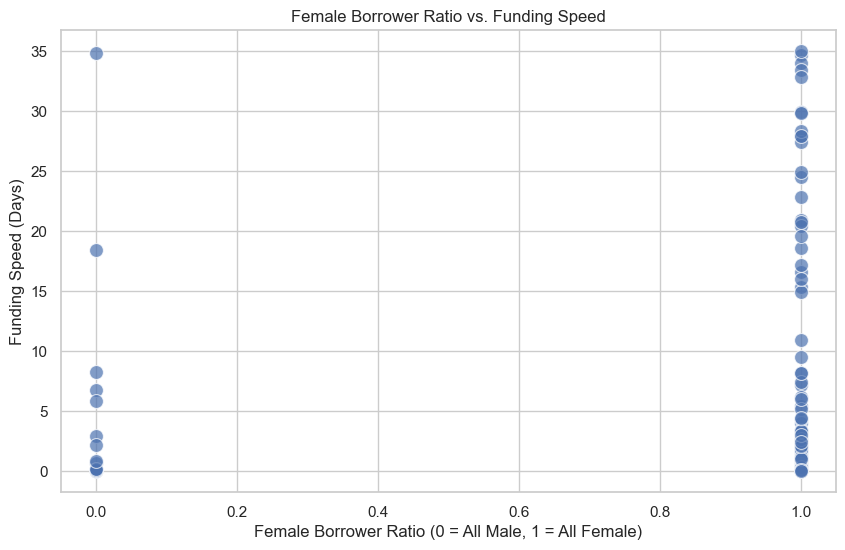

In [6]:
# Group vs Individual
df['is_group'] = df['borrowerCount'] > 1
plt.figure()
sns.boxplot(data=df, x='is_group', y='funding_speed_days', palette='pastel')
plt.title('Funding Speed: Individual vs. Group Loans')
plt.xlabel('Is Group Loan?')
plt.ylabel('Funding Speed (Days)')
plt.xticks([0, 1], ['Individual', 'Group'])
plt.show()

# Female ratio vs Funding speed
# (We parse gender to get female ratio)
from src.features import extract_borrower_features
df_gender = extract_borrower_features(df)

plt.figure()
sns.scatterplot(data=df_gender, x='female_ratio', y='funding_speed_days', alpha=0.7, s=100)
plt.title('Female Borrower Ratio vs. Funding Speed')
plt.xlabel('Female Borrower Ratio (0 = All Male, 1 = All Female)')
plt.ylabel('Funding Speed (Days)')
plt.show()


## 3. Feature Engineering and Narrative (Text) Analysis
Kiva loans include description and use texts. The narrative quality and framing 
(e.g. personal, family-focused, business-focused) represent key marketing levers.


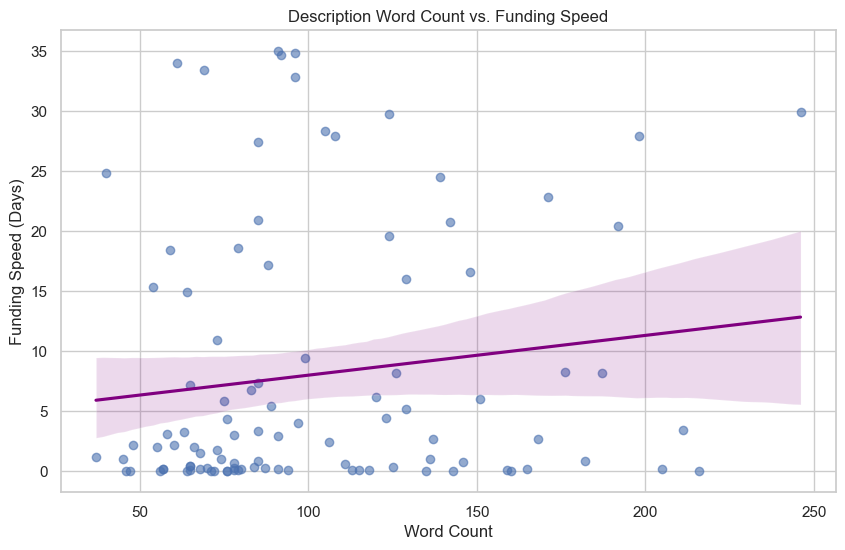

F:\Storage\Temp\ipykernel_26456\2343381705.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df_feat, x='has_family_focus', y='funding_speed_days', palette='Set2')
F:\Storage\Temp\ipykernel_26456\2343381705.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Mention', 'Mentioned'])
F:\Storage\Temp\ipykernel_26456\2343381705.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_feat, x='has_business_focus', y='funding_speed_days', palette='Set2')


F:\Storage\Temp\ipykernel_26456\2343381705.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Mention', 'Mentioned'])


<Figure size 1000x600 with 0 Axes>

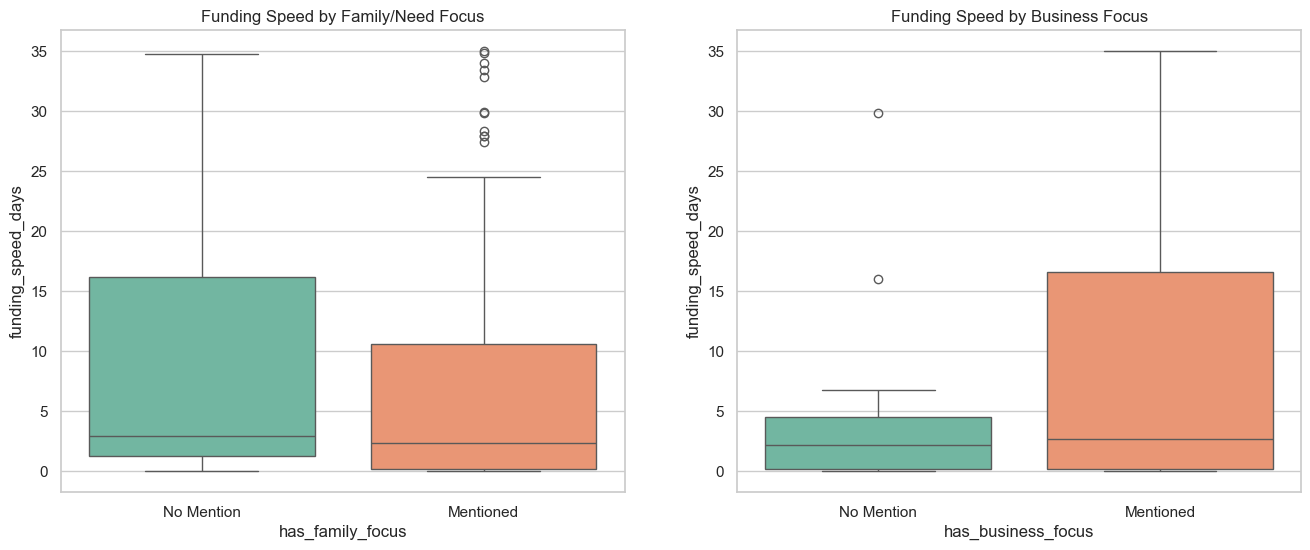

In [7]:
# Apply feature engineering
df_feat = build_features(df)

# Plot word count vs funding speed
plt.figure()
sns.regplot(data=df_feat, x='desc_word_count', y='funding_speed_days', scatter_kws={'alpha':0.6}, line_kws={'color':'purple'})
plt.title('Description Word Count vs. Funding Speed')
plt.xlabel('Word Count')
plt.ylabel('Funding Speed (Days)')
plt.show()

# Check family focus vs business focus
plt.figure()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(ax=axes[0], data=df_feat, x='has_family_focus', y='funding_speed_days', palette='Set2')
axes[0].set_title('Funding Speed by Family/Need Focus')
axes[0].set_xticklabels(['No Mention', 'Mentioned'])

sns.boxplot(ax=axes[1], data=df_feat, x='has_business_focus', y='funding_speed_days', palette='Set2')
axes[1].set_title('Funding Speed by Business Focus')
axes[1].set_xticklabels(['No Mention', 'Mentioned'])
plt.show()


### 3.1 Narrative Sentiment Analysis (VADER)
Let's explore how the sentiment (emotional tone) of the borrower's description 
relates to funding speed. We look at the VADER compound sentiment score, which 
ranges from -1 (extremely negative) to +1 (extremely positive).


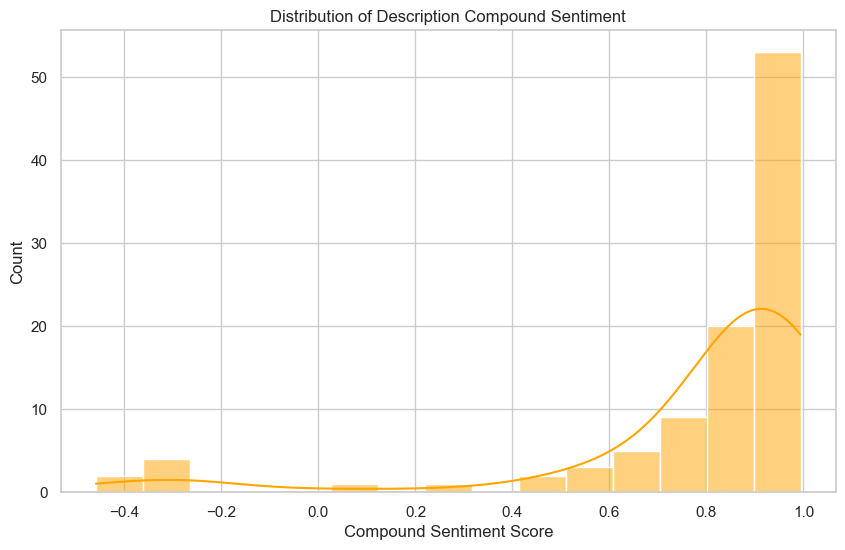

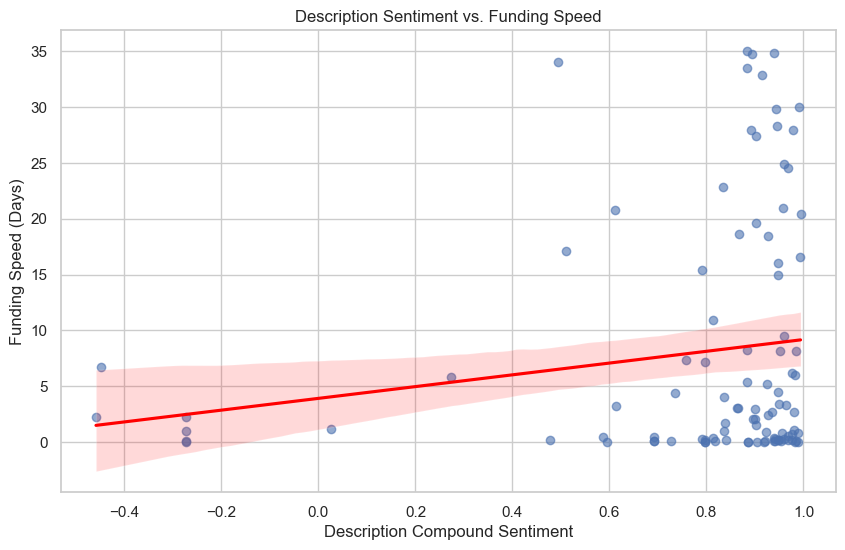

Correlation between Description Sentiment and Funding Speed: 0.158


In [8]:
# Plot Sentiment Distribution
plt.figure()
sns.histplot(df_feat['desc_sentiment_compound'], kde=True, bins=15, color='orange')
plt.title('Distribution of Description Compound Sentiment')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Count')
plt.show()

# Scatter plot: Sentiment vs Funding Speed
plt.figure()
sns.regplot(data=df_feat, x='desc_sentiment_compound', y='funding_speed_days', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Description Sentiment vs. Funding Speed')
plt.xlabel('Description Compound Sentiment')
plt.ylabel('Funding Speed (Days)')
plt.show()

# Correlation
sentiment_corr = df_feat['desc_sentiment_compound'].corr(df_feat['funding_speed_days'])
print(f"Correlation between Description Sentiment and Funding Speed: {sentiment_corr:.3f}")


### 3.2 Narrative Topic Modeling (NMF)
Let's extract hidden themes (topics) from the loan descriptions using Non-Negative Matrix 
Factorization (NMF) and see how the theme of the request affects its funding speed.


Topic 0 Top Words: like, years, like save, store, children, general
Topic 1 Top Words: business, school, loan, children, buy, years
Topic 2 Top Words: sanitary, sanitary toilet, toilet, hazard risks, health hazard, risks
Topic 3 Top Words: farm, farming, inputs, agricultural, farmer, make
Topic 4 Top Words: nwtf, business, loans nwtf, business activities, sustaining, sustaining business

--- Topic Speed Analysis ---
Dominant Topic Distribution and Mean Funding Speed:

Topic 0 (Top Keywords: like, years, like save, store, children):
  - Count of Loans: 13
  - Mean Funding Speed: 3.65 days
  - Median Funding Speed: 1.00 days

Topic 1 (Top Keywords: business, school, loan, children, buy):
  - Count of Loans: 55
  - Mean Funding Speed: 9.45 days
  - Median Funding Speed: 3.08 days

Topic 2 (Top Keywords: sanitary, sanitary toilet, toilet, hazard risks, health hazard):
  - Count of Loans: 4
  - Mean Funding Speed: 0.93 days
  - Median Funding Speed: 0.74 days

Topic 3 (Top Keywords: farm, f

F:\Storage\Temp\ipykernel_26456\1674879169.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_topics, x='dominant_topic', y='funding_speed_days', palette='Set3')


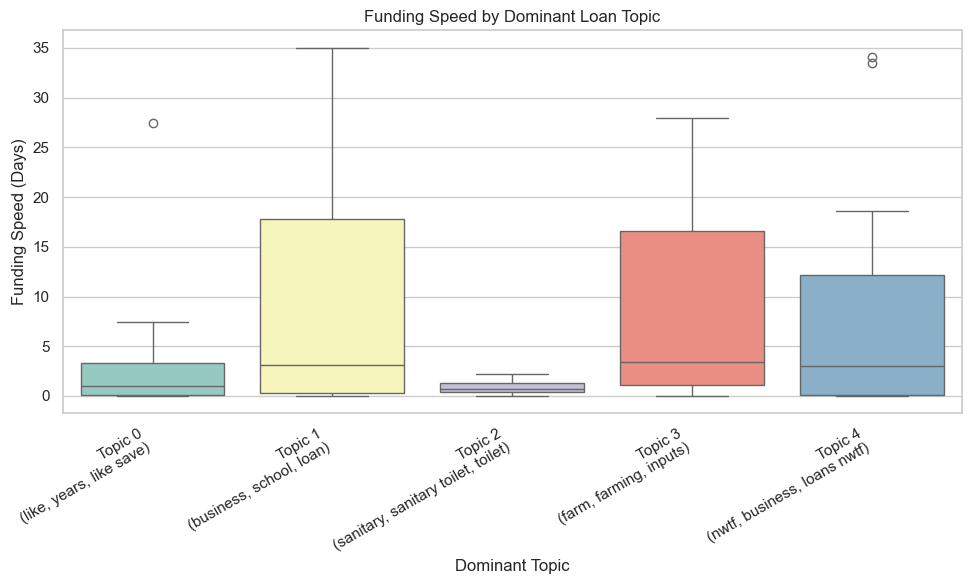

In [9]:
from src.topics import extract_topics_nmf, analyze_topics_speed
df_topics, topic_keywords = extract_topics_nmf(df, n_topics=5)

# Print topics and keywords
for idx, words in topic_keywords.items():
    print(f"Topic {idx} Top Words: {', '.join(words[:6])}")

# Print mean speed per dominant topic
analyze_topics_speed(df_topics, topic_keywords)

# Boxplot of dominant topic vs funding speed
plt.figure(figsize=(10, 6))
# Create labels for boxplot x-axis using the first 3 keywords
labels = [f"Topic {i}\n({', '.join(words[:3])})" for i, words in topic_keywords.items()]
sns.boxplot(data=df_topics, x='dominant_topic', y='funding_speed_days', palette='Set3')
plt.xticks(ticks=range(5), labels=labels, rotation=30, ha='right')
plt.title('Funding Speed by Dominant Loan Topic')
plt.xlabel('Dominant Topic')
plt.ylabel('Funding Speed (Days)')
plt.tight_layout()
plt.show()


## 4. Baseline Modeling & Feature Influence
Let's run the modeling pipeline to predict funding speed and look at the variables 
that are most predictive of speed.


In [10]:
X, y, ridge_model, rf_model = run_baseline_model(pkl_path)


Loading and preprocessing data...


Building features...


Number of features selected for modeling: 64
Number of records: 100

--- Training Ridge Regression Model ---
Train MAE:   3.2447
Test MAE:    11.4742
Test RMSE:   13.9432
Test R2:     -0.5108

Top 10 Ridge Regression Coefficients (Influence on funding speed):
(Positive coefficient = increases funding time / slows funding)
(Negative coefficient = decreases funding time / speeds up funding)
                  Feature  Coefficient
         sector_Education    -9.212332
          log_loan_amount     6.354424
             repay_at_end    -6.176925
          sector_Services     5.993458
              sector_Arts    -5.795402
          sector_Clothing     5.713784
            is_group_loan    -5.343033
log_funds_lent_in_country     4.881921
            region_Africa     4.854293
   use_sentiment_compound     4.846926

--- Training Random Forest Regressor ---


C:\Users\ThinkPad\.pyenv\pyenv-win\versions\3.11.4\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07123e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


Test MAE:    9.2885
Test RMSE:   11.1084
Test R2:     0.0411

Top 10 Random Forest Feature Importances:
                Feature  Importance
        log_loan_amount    0.197371
             loanAmount    0.184550
desc_sentiment_compound    0.060071
          borrowerCount    0.045500
     third_person_count    0.045422
    monthly_payment_est    0.042082
        desc_word_count    0.038015
    lenderRepaymentTerm    0.030880
      use_sentiment_neu    0.024961
     desc_sentiment_pos    0.024778


### 4.1 Feature Importances (Random Forest)
Visualize which variables have the highest predictive power for funding speed.


F:\Storage\Temp\ipykernel_26456\1714055435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='crest')


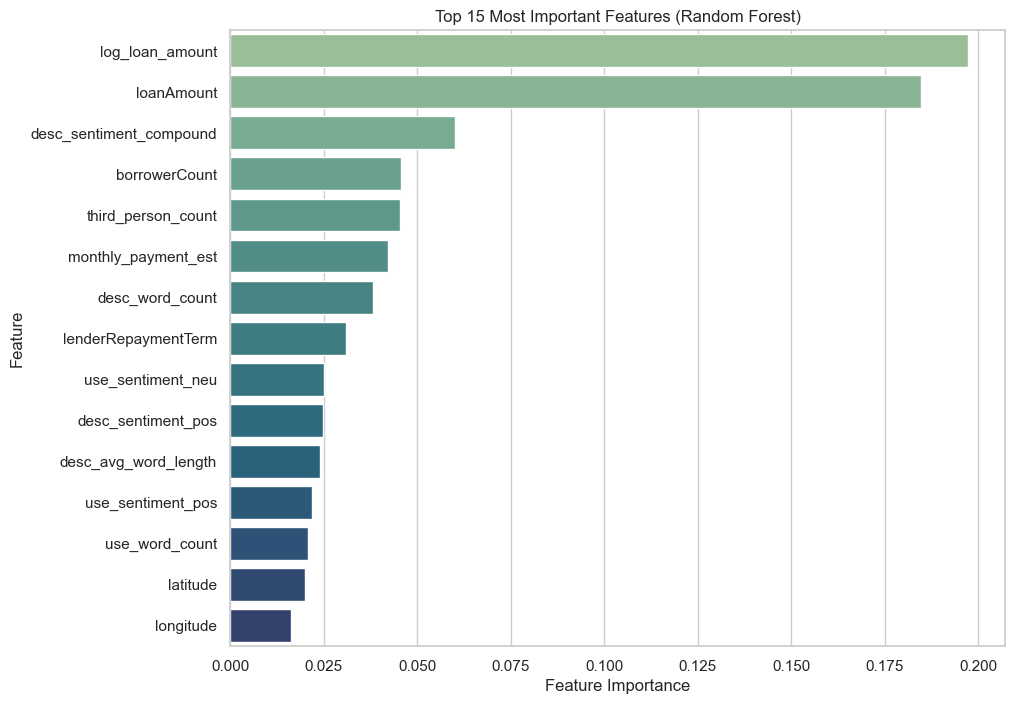

In [11]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(15), x='Importance', y='Feature', palette='crest')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.show()


## Next Steps for the Hackathon:
1. **Interaction Effects**: Check if the impact of narrative framing (e.g. sentiment or family focus) varies across regions/sectors. For example, does positive sentiment matter more in Africa or Asia?
2. **Topic Modeling**: Use LDA (Latent Dirichlet Allocation) to extract topics from descriptions (e.g. farming, education, emergency) and see how topic mix affects speed.
3. **Advanced Models**: Try LightGBM, XGBoost, or CatBoost, tuning hyperparameters using cross-validation.
4. **Additional Text Features**: Score readability (Flesch-Kincaid) or check for specific stylistic metrics like punctuation (exclamations, question marks).
